# SIR
----


## Bibliotecas

In [1]:
import os
os.environ['DDE_BACKEND'] = 'pytorch'
import numpy as np
import matplotlib.pyplot as plt
import scipy
import deepxde as dde

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# https://deepxde.readthedocs.io/en/latest/modules/deepxde.optimizers.html#module-deepxde.optimizers.config
dde.config.set_default_float("float64")

# Para reprodução dos experimentos
np.random.seed(42)
dde.config.set_random_seed(42)

Set the default float type to float64


## Modelo SIR

$$
\frac{dS}{dt} = −βSI
$$
$$
\frac{dI}{dt} = βSI − γI
$$
$$
\frac{dR}{dt} = γI.
$$

In [3]:
beta = 1.5
gamma = 0.8

In [4]:
def sir_model(t, y):

    S, I, R = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    
    dS_dt = dde.grad.jacobian(y, t, i=0)
    dI_dt = dde.grad.jacobian(y, t, i=1)
    dR_dt = dde.grad.jacobian(y, t, i=2)
    
    return [
        dS_dt - (-beta * S * I),
        dI_dt - (beta * S * I - gamma * I),
        dR_dt - (gamma * I)   
    ]

## Limites

In [5]:
t0, tf = 0, 30
geom = dde.geometry.TimeDomain(t0, tf)

## Condições iniciais

In [6]:
S0 = 0.99
I0 = 0.01
R0 = 0.00

ic_S = dde.icbc.IC(geom, lambda _: S0, lambda _, on_initial: on_initial, component=0)
ic_I = dde.icbc.IC(geom, lambda _: I0, lambda _, on_initial: on_initial, component=1)
ic_R = dde.icbc.IC(geom, lambda _: R0, lambda _, on_initial: on_initial, component=2)

## Dados de treinamento

In [7]:
data = dde.data.PDE(
    geom, 
    sir_model, 
    [ic_S, ic_I, ic_R],
    num_domain=100, 
    num_boundary=2,
    num_test=50
)

## Configuração da rede

In [8]:
net = dde.nn.FNN([1] + [50] * 3 + [3], "tanh", "Glorot uniform")
model = dde.Model(data, net)
model.compile("adam", lr=0.001)

Compiling model...
'compile' took 2.191378 s



## Treinamento

In [9]:
losshistory, train_state = model.train(
    iterations=20000, 
    model_save_path="../modelos/sir")

dde.saveplot(
    losshistory, 
    train_state, 
    output_dir="../treinamentos",
    loss_fname="sir_losses.dat",
    train_fname="sir_train.dat",
    test_fname="sir_test.dat",
    issave=True, 
    isplot=False)

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.71e-02, 1.40e-01, 5.61e-02, 9.80e-01, 1.00e-04, 0.00e+00]    [2.60e-02, 1.43e-01, 5.55e-02, 9.80e-01, 1.00e-04, 0.00e+00]    []  
1000      [1.50e-05, 1.17e-05, 1.51e-06, 1.76e-09, 3.31e-07, 8.77e-13]    [6.46e-06, 1.19e-05, 1.55e-06, 1.76e-09, 3.31e-07, 8.77e-13]    []  
2000      [2.66e-05, 5.83e-05, 2.35e-05, 1.93e-10, 9.35e-07, 1.89e-09]    [2.55e-05, 5.53e-05, 2.42e-05, 1.93e-10, 9.35e-07, 1.89e-09]    []  
3000      [7.73e-06, 2.51e-05, 2.47e-07, 9.71e-09, 8.91e-08, 3.04e-13]    [5.39e-06, 2.55e-05, 2.11e-07, 9.71e-09, 8.91e-08, 3.04e-13]    []  
4000      [5.24e-06, 2.30e-05, 1.72e-07, 8.63e-09, 9.46e-08, 4.47e-13]    [3.83e-06, 2.35e-05, 1.62e-07, 8.63e-09, 9.46e-08, 4.47e-13]    []  
5000      [4.98e-06, 2.79e-05, 4.15e-06, 5.29e-09, 1.19e-11, 2.21e-09]    [4.23e-06, 2.85e-05, 4.25e-06, 5.29e-09, 1

## Visualizando resultados

In [10]:
def plot_and_save_solution(solution, t_test, file_path):

    S, I, R = solution[:, 0], solution[:, 1], solution[:, 2]

    plt.plot(t_test, S, label="Suscetíveis (S)", linewidth=5)
    plt.plot(t_test, I, label="Infectados (I)", linewidth=5)
    plt.plot(t_test, R, label="Recuperados (R)", linewidth=5)
    
    plt.xlabel("Tempo (t)")
    plt.ylabel("Fração da População")
    
    plt.legend()
    plt.grid()
    plt.savefig(file_path)
    plt.show()

In [11]:
#model.restore("../modelos/sir-20000.pt")

In [12]:
NUMBER_OF_POINTS = 100

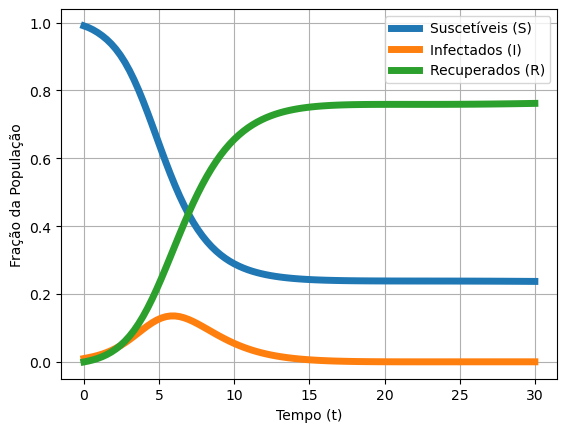

In [13]:
t_test = np.linspace(t0, tf, NUMBER_OF_POINTS)
y_pred = model.predict(t_test.reshape(-1, 1))
plot_and_save_solution(y_pred, t_test, "../figuras/sir_pinns.pdf")

## Comparação com métodos numéricos

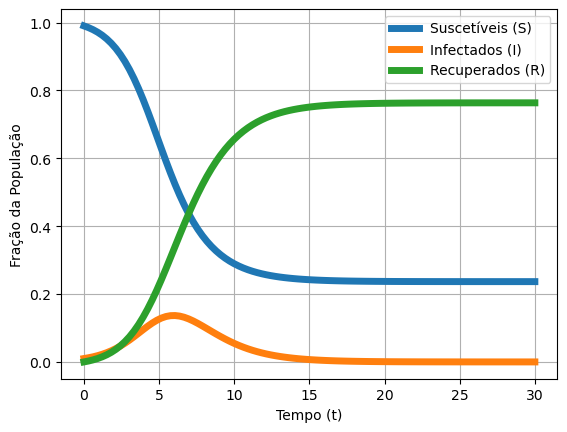

In [14]:

# Modelo SIR: dS/dt = -β S I, dI/dt = β S I - μ I, dR/dt = μ I
def sir_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return np.array([dSdt, dIdt, dRdt])

# Implementação do método RK4
def rk4(f, y0, t, beta, gama):
    n = len(t)
    y = np.zeros((n, len(y0)))
    y[0] = y0

    for i in range(n - 1):
        dt = t[i+1] - t[i]
        k1 = f(y[i], t[i], beta, gama)
        k2 = f(y[i] + dt * k1 / 2, t[i] + dt / 2, beta, gamma)
        k3 = f(y[i] + dt * k2 / 2, t[i] + dt / 2, beta, gamma)
        k4 = f(y[i] + dt * k3, t[i] + dt, beta, gamma)
        y[i+1] = y[i] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return y

# Condições iniciais
y0 = np.array([S0, I0, R0])

# Intervalo de tempo
t = np.linspace(t0, tf, NUMBER_OF_POINTS)  # De 0 a 50, com 100 pontos

# Resolver o sistema SIR com RK4
sol = rk4(sir_model, y0, t, beta, gamma)

plot_and_save_solution(sol, t, "../figuras/sir_rk4.pdf")

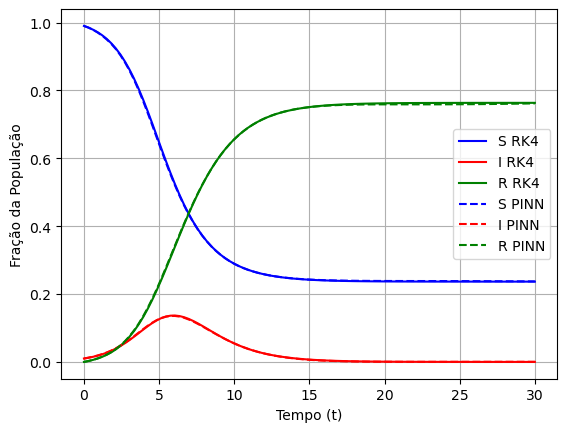

In [22]:

S_rk4, I_rk4, R_rk4 = sol[:, 0], sol[:, 1], sol[:, 2]
S_pinn, I_pinn, R_pinn = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]

plt.plot(t_test, S_rk4, label="S RK4", color="blue")
plt.plot(t_test, I_rk4, label="I RK4", color="red")
plt.plot(t_test, R_rk4, label="R RK4", color="green")

plt.plot(t_test, S_pinn, label="S PINN", color="blue", linestyle="--")
plt.plot(t_test, I_pinn, label="I PINN", color="red", linestyle="--")
plt.plot(t_test, R_pinn, label="R PINN", color="green", linestyle="--")

plt.xlabel("Tempo (t)")
plt.ylabel("Fração da População")

plt.legend()
plt.grid()
plt.savefig("../figuras/resultado-sir.pdf")
plt.show()

## Analisando função de perda

In [ ]:
def plot_and_save_losses(losshistory, file_path):

    X = losshistory.steps
    train = np.sum(losshistory.loss_train, axis=1)
    test = np.sum(losshistory.loss_test, axis=1)
    
    plt.semilogy(X, train, "o-", label="Treinamento", linewidth=2)
    plt.semilogy(X, test, "x-", label="Teste", linewidth=2)

    plt.xlabel("Iteração")
    plt.ylabel("Erro em escala logarítmica")
    
    plt.legend()
    plt.grid()
    plt.savefig(file_path)
    plt.show()

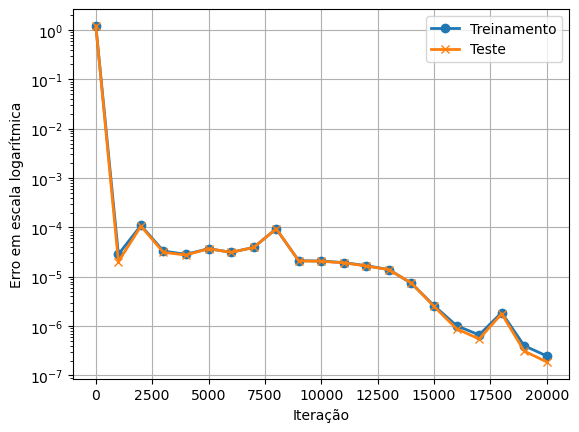

In [ ]:
plot_and_save_losses(losshistory, "../figuras/sir_loss.pdf")

## Diferenças entre PINNs e Runge-Kutta

### Suscetíveis

In [ ]:
np.sqrt(dde.metrics.mean_squared_error(y_pred[:,0], sol[:,0]))

np.float64(0.0017925649842097616)

In [ ]:
scipy.linalg.norm(y_pred[:,0] - sol[:,0], ord=2)

0.017925649842097616

In [ ]:
scipy.linalg.norm(y_pred[:,0] - sol[:,0], ord=np.inf)

np.float64(0.005161406987254535)

### Infectados

In [ ]:
np.sqrt(dde.metrics.mean_squared_error(y_pred[:,1], sol[:,1]))

np.float64(0.0006718146287562511)

In [ ]:
scipy.linalg.norm(y_pred[:,1] - sol[:,1], ord=2)

0.006718146287562512

In [ ]:
scipy.linalg.norm(y_pred[:,1] - sol[:,1], ord=np.inf)

np.float64(0.001715583403136961)

### Recuperados

In [ ]:
np.sqrt(dde.metrics.mean_squared_error(y_pred[:,2], sol[:,2]))

np.float64(0.0024829086373029012)

In [ ]:
scipy.linalg.norm(y_pred[:,2] - sol[:,2], ord=2)

0.02482908637302901

In [ ]:
scipy.linalg.norm(y_pred[:,2] - sol[:,2], ord=np.inf)

np.float64(0.00421413249824687)